In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
from IPython.display import display, HTML

In [10]:
display(HTML("<h1>Data Loading<h1>"))

In [11]:
df = pd.read_csv("spam_ham_dataset.csv")
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [12]:
display(HTML("<h1>Data Cleaning<h1>"))

In [13]:
df['text'].head(5)

0    Subject: enron methanol ; meter # : 988291\r\n...
1    Subject: hpl nom for january 9 , 2001\r\n( see...
2    Subject: neon retreat\r\nho ho ho , we ' re ar...
3    Subject: photoshop , windows , office . cheap ...
4    Subject: re : indian springs\r\nthis deal is t...
Name: text, dtype: object

In [14]:
display(HTML("<h1>Unnamed: 0 kisi kaam ka nahi hai To drop Ker sakte hai<h1>"))

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5171 non-null   int64 
 1   label       5171 non-null   object
 2   text        5171 non-null   object
 3   label_num   5171 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 161.7+ KB


In [7]:
df = df.drop(columns=["Unnamed: 0"])

In [8]:
display(HTML("<h1>Drop Nahi Ho Rahi hai<h1>"))

In [9]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])


In [16]:
df["label_num"].value_counts()

label_num
0    3672
1    1499
Name: count, dtype: int64

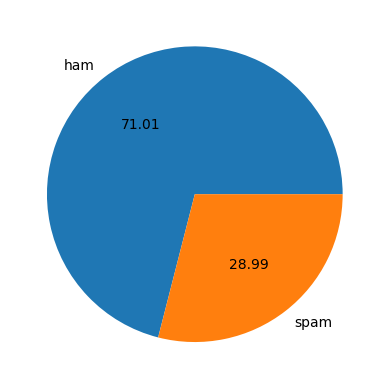

In [15]:
plt.pie(df['label'].value_counts(),labels=['ham',"spam"],autopct="%0.2f")
plt.show()

In [19]:
df.isnull().sum()

Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

In [10]:


df.head()

,label,text,label_num
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,spam,"Subject: photoshop , windows , office . cheap ...",1
4,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [11]:
display(HTML("<h1>Sabko lower case me karna hai"))

In [17]:
display(HTML("<h1>Data Preprocessing<h1>"))

In [12]:
df["text"]=df["text"].str.lower()
df

,label,text,label_num
0,ham,subject: enron methanol ; meter # : 988291\r\n...,0
1,ham,"subject: hpl nom for january 9 , 2001\r\n( see...",0
2,ham,"subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,spam,"subject: photoshop , windows , office . cheap ...",1
4,ham,subject: re : indian springs\r\nthis deal is t...,0
...,...,...,...
5166,ham,subject: put the 10 on the ft\r\nthe transport...,0
5167,ham,subject: 3 / 4 / 2000 and following noms\r\nhp...,0
5168,ham,subject: calpine daily gas nomination\r\n>\r\n...,0
5169,ham,subject: industrial worksheets for august 2000...,0


In [13]:
display(HTML("<h1>Convert text into number by TF-IDF (Term Frequency - Inverse Document Frequency)"))

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf =  TfidfVectorizer(stop_words = 'english',max_features=5000)
x_tfidf = tfidf.fit_transform(df['text'])

In [15]:
print(x_tfidf.shape)

(5171, 5000)


In [16]:
y = df["label_num"]

In [18]:
display(HTML("<h1>Model Training<h1>"))

In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_tfidf,y,test_size=0.2,random_state=42)

In [18]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)


In [19]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

print("Accuracy:",accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.9487922705314009
[[710  32]
 [ 21 272]]
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       742
           1       0.89      0.93      0.91       293

    accuracy                           0.95      1035
   macro avg       0.93      0.94      0.94      1035
weighted avg       0.95      0.95      0.95      1035



In [27]:
import pickle

with open('tfidf2.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('Spam_Emails_classifiers.pkl', 'wb') as f:
    pickle.dump(model, f)
